<a href="https://colab.research.google.com/github/g019-expert/BMEN5801_PS1/blob/main/BMEN5801_ps1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/g019-expert/BMEN5801_PS1.git

import os

DATA = 'BMEN5801_PS1/data'
RESULTS = 'BMEN5801_PS1/figures'
os.makedirs(RESULTS, exist_ok=True)
print(sorted(os.listdir(DATA)))

fatal: destination path 'BMEN5801_PS1' already exists and is not an empty directory.
['ALL_BoneMarrowSmear.png', 'GSE54456_RPKM_samples.csv', 'GSE54456_labels.csv', 'ecg-svt.h5']


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import matplotlib.pyplot as plt
from scipy import signal, stats

# given that sampled at same hz for all leads
FS = 977.0 # hz

LIMB = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF']
CHEST = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']


##Problem 1

In [3]:
df = pd.read_hdf(f'{DATA}/ecg-svt.h5')

print(df.shape)
print(df.columns.tolist())
print(df['record'].value_counts())
print(df.head())
print(df.index.min(), df.index.max())

(1191633, 13)
['record', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
record
x0025    650620
x0021    541013
Name: count, dtype: int64
  record      I     II    III    aVR    aVL    aVF     V1     V2     V3  \
0  x0021  0.010 -0.053 -0.054  0.044  0.039 -0.044 -0.082 -0.175 -0.295   
1  x0021  0.019 -0.058 -0.064  0.049  0.039 -0.053 -0.087 -0.165 -0.290   
2  x0021  0.019 -0.067 -0.069  0.049  0.049 -0.058 -0.087 -0.170 -0.290   
3  x0021  0.014 -0.063 -0.064  0.044  0.044 -0.044 -0.082 -0.160 -0.290   
4  x0021  0.014 -0.038 -0.044  0.029  0.039 -0.024 -0.087 -0.155 -0.286   

      V4     V5     V6  
0 -0.124 -0.048 -0.024  
1 -0.124 -0.043 -0.029  
2 -0.124 -0.048 -0.034  
3 -0.124 -0.043 -0.029  
4 -0.124 -0.048 -0.034  
0 1191632


x0021: R at 0.176 s, RR = 0.379 s (158.2 bpm)
x0025: R at 0.801 s, RR = 0.528 s (113.7 bpm)


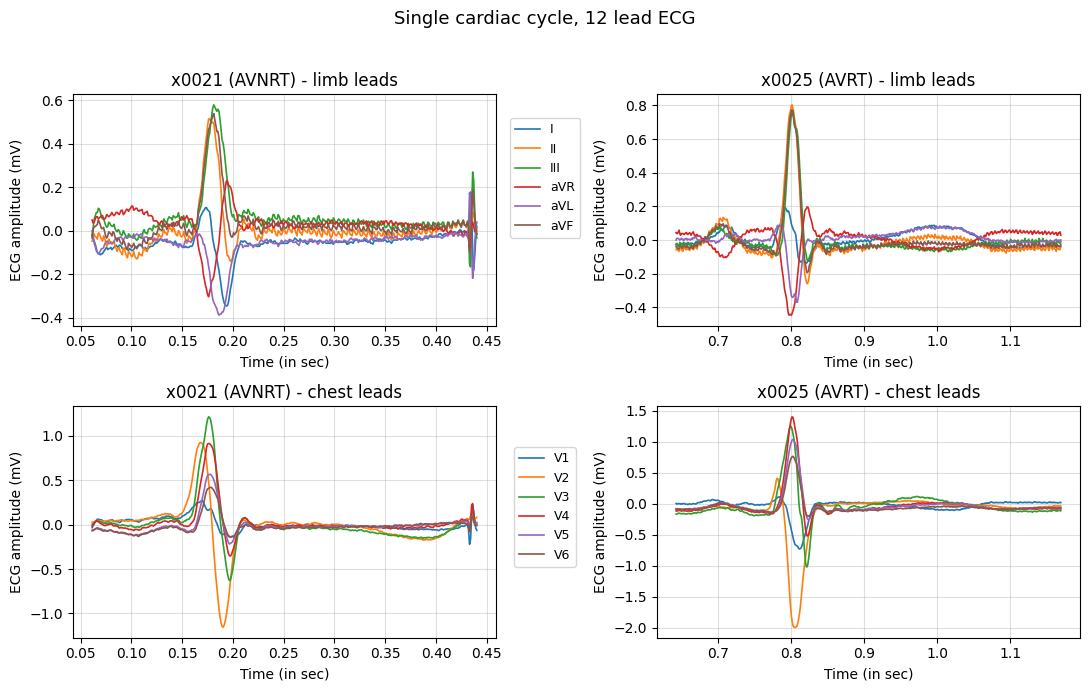

In [4]:
# 1(a) limb leads top, chest leads below (x0021 on left and x0025 right col)

PATIENTS = [('x0021','AVNRT'), ('x0025','AVRT')]

from scipy.signal import find_peaks

fig, axes = plt.subplots(2, 2, figsize=(11, 7))


# return (low, high, r_0, rr) sample bounds around the first clean cardiac cycle
# both x0021 and x0025
def first_beat_window(sig, fs=FS, guard_s=0.05, n_rr=4): # 50 ms power on guard
    x = sig - np.median(sig[:int(5*fs)])
    pk, _ = find_peaks(np.abs(x), height=0.5*np.max(np.abs(x[:int(10*fs)])),
                       distance=int(0.2*fs))
    rr = np.median(np.diff(pk[:n_rr+1])) / fs
    # first beat
    for r0 in pk:
        lo, hi = int(r0 - 0.30*rr*fs), int(r0 + 0.70*rr*fs)
        if lo >= int(guard_s*fs):
            return lo, hi, r0, rr

# locate each patient record
def get_record(df, rec):
  return df.loc[df['record'] == rec].reset_index(drop=True)

for col, (rec, dx) in enumerate(PATIENTS):
    d = get_record(df, rec)
    # lead II timing reference
    lo, hi, r0, rr = first_beat_window(d['II'].values)
    t = np.arange(lo, hi) / FS

    for row, leads in enumerate([LIMB, CHEST]):
        ax = axes[row, col]
        for L in leads:
            v = d[L].values[lo:hi] - np.median(d[L].values[:int(5*FS)])
            ax.plot(t, v, lw=1.2, label=L)
        ax.set_xlabel('Time (in sec)')
        ax.set_ylabel('ECG amplitude (mV)')
        ax.set_title(f'{rec} ({dx}) - {"limb" if row==0 else "chest"} leads')
        ax.grid(True, alpha=0.4)

    print(f'{rec}: R at {r0/FS:.3f} s, RR = {rr:.3f} s ({60/rr:.1f} bpm)')

fig.legend(handles=axes[0,0].get_legend_handles_labels()[0],
           loc='center', bbox_to_anchor=(0.5, 0.74), frameon=True, fontsize=9)
fig.legend(handles=axes[1,0].get_legend_handles_labels()[0],
           loc='center', bbox_to_anchor=(0.5, 0.27), frameon=True, fontsize=9)

fig.suptitle('Single cardiac cycle, 12 lead ECG', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(wspace=0.38)
fig.savefig(f'{RESULTS}/p1a_first_beat.png', dpi=200, bbox_inches='tight')
plt.show()

The QRS polarity varies across leads within each patient because the lead porjects the same QRS vector onto a different axis, so the leads near the vector (II, III, aVF) are upright and leads opposing it (aVR, aVL) are negative. And lead perpendicular is close to I.

In [5]:
# 1(b) mean QRS vector in frontal plane for each patient and limb lead for each patient

# positive - negative deflection, referenced from lecture to measure net qrs deflection

LEAD_ANGLE = {'I': 0, 'II': 60, 'III': 120, 'aVR': -150, 'aVL': -30, 'aVF': 90}

def ang_diff(a, b):
    return abs((a - b + 180) % 360 - 180)

def qrs_net_deflection(sig, r0, fs=FS, qrs_half=0.05, pr_win=(0.08, 0.04)):
    # net QRS = positive peak + negative peak
    base = np.median(sig[r0 - int(pr_win[0]*fs): r0 - int(pr_win[1]*fs)])
    qrs = sig[r0 - int(qrs_half*fs): r0 + int(qrs_half*fs)] - base # (base from PR)
    return qrs.max() + qrs.min()

axis_results = {}
for rec, dx in PATIENTS:
    d = get_record(df, rec)
    lo, hi, r0, rr = first_beat_window(d['II'].values)
    net = {L: qrs_net_deflection(d[L].values, r0) for L in LIMB}

    # signs of I and aVF give the quadrant and |net| < 10% of max treated as equiphasic
    tol = 0.1 * max(abs(v) for v in net.values())
    sgn = lambda v: '0' if abs(v) < tol else ('+' if v > 0 else '-')
    I_s, aVF_s = sgn(net['I']), sgn(net['aVF'])
    quadrant = {('+','+'): 'normal (0 to +90)', ('+','-'): 'left (0 to -90)',
                ('-','+'): 'right (+90 to 180)', ('-','-'): 'extreme (-90 to 180)',
                ('0','+'): 'on the +90 border', ('0','-'): 'on the -90 border',
                ('+','0'): 'on the 0 border', ('-','0'): 'on the 180 border'}.get((I_s, aVF_s), 'indeterminate')

    # find lead with largest positive deflection
    tallest = max(LIMB, key=lambda L: net[L])
    equiphasic = min(LIMB, key=lambda L: abs(net[L]))

    # mean QRS vector, using least squares fit of net_k
    th = np.deg2rad([LEAD_ANGLE[L] for L in LIMB])
    A = np.column_stack([np.cos(th), np.sin(th)])
    (vx, vy), *_ = np.linalg.lstsq(A, np.array([net[L] for L in LIMB]), rcond=None)
    axis = np.degrees(np.arctan2(vy, vx))
    aligned = min(LIMB, key=lambda L: ang_diff(axis, LEAD_ANGLE[L]))
    axis_results[rec] = (axis, aligned)

    print(f'{rec} ({dx}) beat at R = {r0/FS:.3f} s')
    for L in LIMB:
        print(f'{L:>4} ({LEAD_ANGLE[L]:+4d} deg): net QRS = {net[L]:+.3f} mV')
    print(f'I {I_s}, aVF {aVF_s} belongs to {quadrant}')
    print(f'largest positive deflection: {tallest}')
    print(f'most equiphasic: {equiphasic} (axis perpendicular to {LEAD_ANGLE[equiphasic]:+d} deg)')
    print(f'QRS axis = {axis:+.1f} deg, so limb lead that closely aligns with QRS vector is: {aligned}\n')

x0021 (AVNRT) beat at R = 0.176 s
   I (  +0 deg): net QRS = -0.096 mV
  II ( +60 deg): net QRS = +0.528 mV
 III (+120 deg): net QRS = +0.594 mV
 aVR (-150 deg): net QRS = -0.221 mV
 aVL ( -30 deg): net QRS = -0.326 mV
 aVF ( +90 deg): net QRS = +0.588 mV
I -, aVF + belongs to right (+90 to 180)
largest positive deflection: III
most equiphasic: I (axis perpendicular to +0 deg)
QRS axis = +96.8 deg, so limb lead that closely aligns with QRS vector is: aVF

x0025 (AVRT) beat at R = 0.801 s
   I (  +0 deg): net QRS = +0.120 mV
  II ( +60 deg): net QRS = +0.668 mV
 III (+120 deg): net QRS = +0.681 mV
 aVR (-150 deg): net QRS = -0.348 mV
 aVL ( -30 deg): net QRS = -0.276 mV
 aVF ( +90 deg): net QRS = +0.656 mV
I +, aVF + belongs to normal (0 to +90)
largest positive deflection: III
most equiphasic: I (axis perpendicular to +0 deg)
QRS axis = +85.3 deg, so limb lead that closely aligns with QRS vector is: aVF



x0021, QRS axis = +97deg, most closely aligned with lead aVF
x0025, QRS axis = +85deg, most closely aligned with lead aVF

aVR and aVL are both -ive so deplarization heads away from both upper left and upper right leads, and II, III, and aVF all have equal net deflections (within small mV), and thus the axis uses a least square vector fit over all 6 limb leads, and closest alignment is decided with the one whose angle is closest to that vector

x0021: 1664 beats over 553.7 s, median HR 245.3 bpm, range 87.8 to 276.5 bpm
x0025: 1755 beats over 665.9 s, median HR 171.4 bpm, range 48.1 to 288.8 bpm


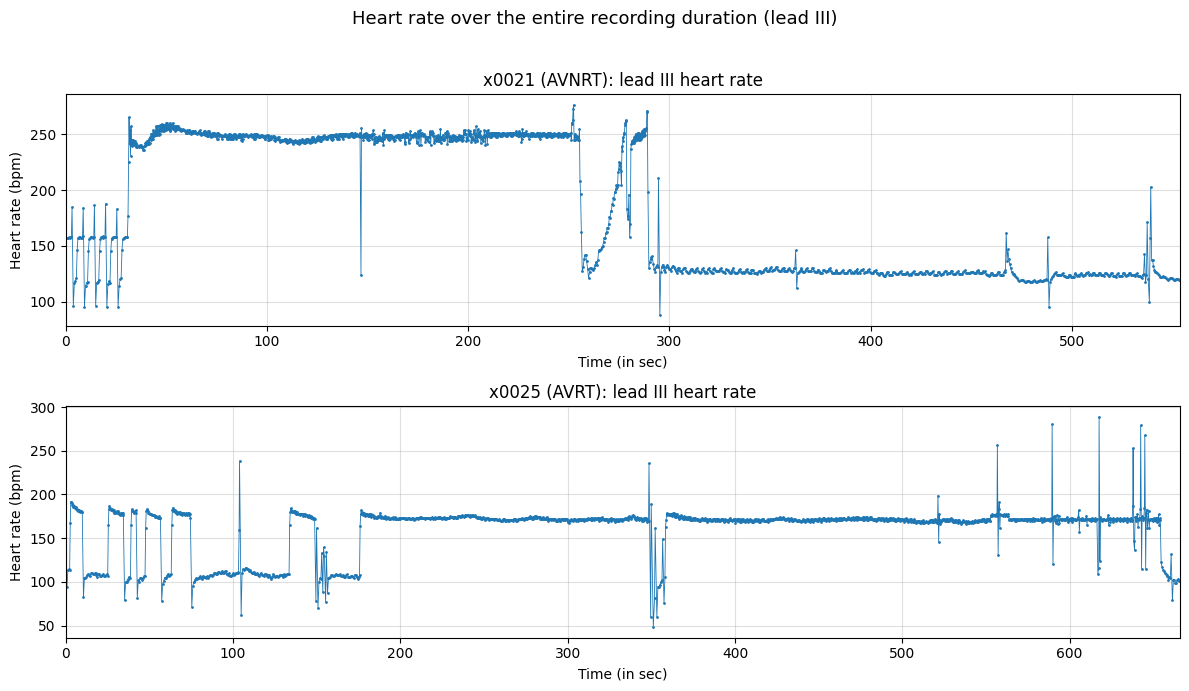

In [6]:
# 1(c)
# lead III for both recrods sampled at same FS, and determine instant HR againt time for whole recording
from scipy import ndimage as ndi

# after i tested find_peaks with 1 threshold it broke on the given data because
# both records contains tall spikes. so picking those R peaks and applying median filter
# to remove those and still leave QRS as is

def detect_r_peaks(x, fs=FS, frac=0.35):
    xm = signal.medfilt(x, int(0.02*fs) | 1) # median filter to fremove spikes but qrs intact
    b, a = signal.butter(2, [0.5, 40], btype='band', fs=fs)
    y = signal.filtfilt(b, a, xm)
    # local R height (0.8 s max), then a 5 s median so one large ectopc beat can't push the threshold over its neighbours
    step = int(0.05*fs)
    loc_max = ndi.maximum_filter1d(y, int(0.8*fs))[::step]
    r_level = np.repeat(ndi.median_filter(loc_max, int(5*fs/step)), step)[:len(y)]
    # peaks observed at least 200 ms apart and above 35% of local R height, hr is capped at 300
    pk, _ = find_peaks(y, distance=int(0.2*fs))
    return pk[y[pk] > frac*r_level[pk]]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (rec, dx) in zip(axes, PATIENTS):
    x = get_record(df, rec)['III'].values.astype(float)
    pk = detect_r_peaks(x)
    rr = np.diff(pk) / FS
    hr = 60 / rr
    t_beat = pk[1:] / FS

    ax.plot(t_beat, hr, lw=0.6, marker='.', ms=2)
    ax.set_xlim(0, len(x)/FS)
    ax.set_xlabel('Time (in sec)')
    ax.set_ylabel('Heart rate (bpm)')
    ax.set_title(f'{rec} ({dx}): lead III heart rate')
    ax.grid(True, alpha=0.4)

    print(f'{rec}: {len(pk)} beats over {len(x)/FS:.1f} s, '
          f'median HR {np.median(hr):.1f} bpm, range {hr.min():.1f} to {hr.max():.1f} bpm')

fig.suptitle('Heart rate over the entire recording duration (lead III)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f'{RESULTS}/p1c_heart_rate.png', dpi=200, bbox_inches='tight')
plt.show()

spikes are real premature in x0025 and the one missed ectopic beat in x0021 at about 150 sec can be seen from the plot

##Problem 2

Otsu threshold on b*: -24.8
Lymphoblasts: 83  (68 fully inside, 15 partially cut by the border)


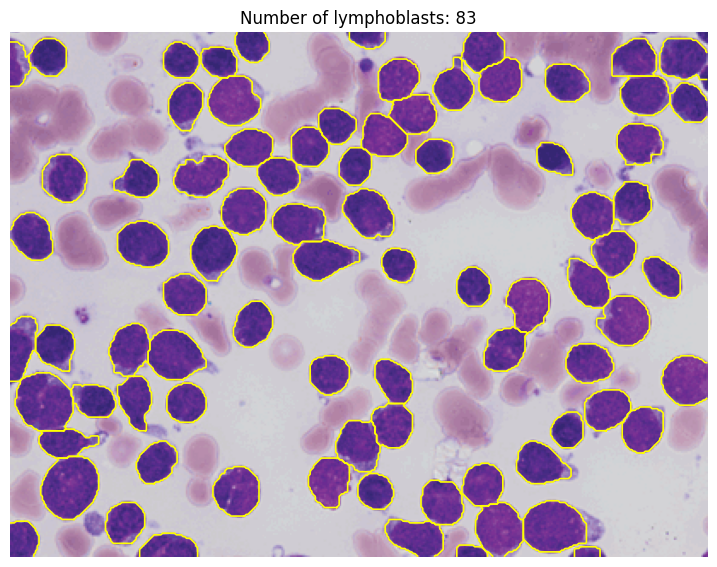

In [7]:
# 2(a)
#lymphoblasts are purple and rbc are pink, return # of lymphoblasts and watershed seg
# given RGBS, so alpha is dropped

from skimage import io, color, filters, measure, segmentation, feature

img = io.imread(f'{DATA}/ALL_BoneMarrowSmear.png')[..., :3]
lab = color.rgb2lab(img)
b_star = lab[..., 2] # hist is clean bimodal

# otsu on b* to separate purple cells from rbcs and the background
t_blast = filters.threshold_otsu(b_star)
blast_mask = filters.gaussian(b_star, sigma=1) < t_blast
blast_mask = ndi.binary_opening(blast_mask, structure=np.ones((5, 5)))
blast_mask = ndi.binary_fill_holes(blast_mask)

# watershed
dist = filters.gaussian(ndi.distance_transform_edt(blast_mask), sigma=1.5)
peaks = feature.peak_local_max(dist, min_distance=9, labels=measure.label(blast_mask), exclude_border=False)
markers = np.zeros(blast_mask.shape, dtype=int)
markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)
blast_lbl = segmentation.watershed(-dist, markers, mask=blast_mask)

# small fragments
props = measure.regionprops(blast_lbl)
med_area = np.median([p.area for p in props])
H, W = blast_mask.shape
def touches_border(p):
    r0, c0, r1, c1 = p.bbox
    return r0 == 0 or c0 == 0 or r1 == H or c1 == W
# cells under 35% of median area are kept and down to 10% also allowed
keep = [p.label for p in props
        if p.area >= 0.35*med_area or (touches_border(p) and p.area >= 0.10*med_area)]
blast_lbl = segmentation.relabel_sequential(np.where(np.isin(blast_lbl, keep), blast_lbl, 0))[0]
n_blasts = blast_lbl.max()
n_edge = sum(touches_border(p) for p in measure.regionprops(blast_lbl))

print(f'Otsu threshold on b*: {t_blast:.1f}')
print(f'Lymphoblasts: {n_blasts}  ({n_blasts - n_edge} fully inside, {n_edge} partially cut by the border)')

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(img)
for k in range(1, n_blasts + 1):
    for c in measure.find_contours(blast_lbl == k, 0.5):
        ax.plot(c[:, 1], c[:, 0], color='yellow', lw=1.2)
ax.set_title(f'Number of lymphoblasts: {n_blasts}')
ax.axis('off')
fig.savefig(f'{RESULTS}/p2a_lymphoblasts.png', dpi=200, bbox_inches='tight')
plt.show()

Red blood cells: 55  (42 fully inside, 13 partially cut by the border)


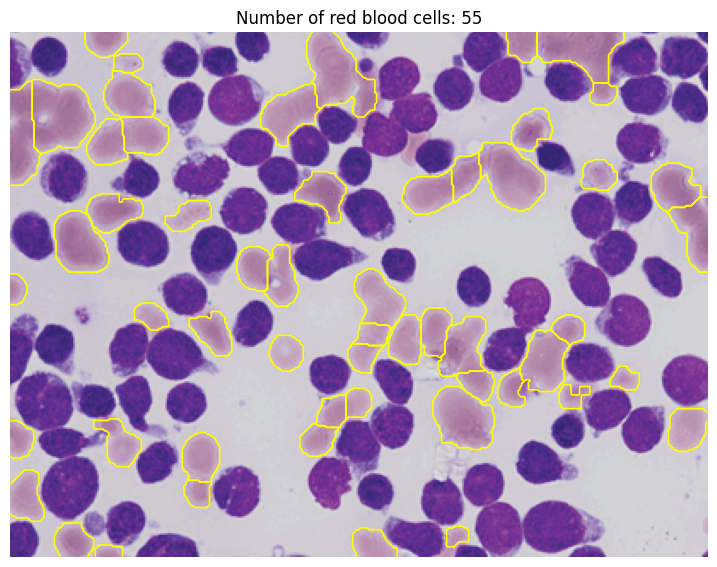

In [8]:
# 2(b)
# contours around rbcs only and rbc count
# a*, different colour channel

a_star = lab[..., 1]

# reddish (a* > 6) and not bluish (b* > -20)
rbc_mask = ((filters.gaussian(a_star, sigma=1) > 6) &
            (filters.gaussian(b_star, sigma=1) > -20) &
            ~ndi.binary_dilation(blast_mask, iterations=2)) # not inside or on the rim of a blast
rbc_mask = ndi.binary_opening(rbc_mask, structure=np.ones((5, 5)))
rbc_mask = ndi.binary_fill_holes(rbc_mask)

# watershed
dist = filters.gaussian(ndi.distance_transform_edt(rbc_mask), sigma=1.0)
# markers allowed down to 5 px apart  (becase overlapping rbcs have centers closer (vs 9 px for the non-overlapping blasts)
peaks = feature.peak_local_max(dist, min_distance=5, labels=measure.label(rbc_mask),
                               exclude_border=False)
markers = np.zeros(rbc_mask.shape, dtype=int)
markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)
rbc_lbl = segmentation.watershed(-dist, markers, mask=rbc_mask)

# keep/drop fragments (using border rule as 2(a));
# rbcs partly hidden behind blasts are small, so the interior floor is 25% of the median area
props = measure.regionprops(rbc_lbl)
med_area = np.median([p.area for p in props])
keep = [p.label for p in props
        if p.area >= 0.25*med_area or (touches_border(p) and p.area >= 0.10*med_area)]
rbc_lbl = segmentation.relabel_sequential(np.where(np.isin(rbc_lbl, keep), rbc_lbl, 0))[0]
n_rbc = rbc_lbl.max()
n_rbc_edge = sum(touches_border(p) for p in measure.regionprops(rbc_lbl))

print(f'Red blood cells: {n_rbc}  ({n_rbc - n_rbc_edge} fully inside, {n_rbc_edge} partially cut by the border)')

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(img)
for k in range(1, n_rbc + 1):
    for c in measure.find_contours(rbc_lbl == k, 0.5):
        ax.plot(c[:, 1], c[:, 0], color='yellow', lw=1.2)
ax.set_title(f'Number of red blood cells: {n_rbc}')
ax.axis('off')
fig.savefig(f'{RESULTS}/p2b_rbc.png', dpi=200, bbox_inches='tight')
plt.show()

RBCs segmented on CIELAB a* channel. grey background is zero and pink rbcs are strong +ive. bluish pixels (b* < -20) or inside or next to lymphoblast identified from 2(a) are excluded. otsu on a* at 11 clipped some pale RBCs, so condition changed to a*>6 meaning just above background level. overlapping rbcs are split using marker watershed. total RBC count is 55

In [9]:
# 2(c)
pct_all = 100 * n_blasts / (n_blasts + n_rbc) # ALL diagnosis
n_blasts_in, n_rbc_in = n_blasts - n_edge, n_rbc - n_rbc_edge
pct_in = 100 * n_blasts_in / (n_blasts_in + n_rbc_in)

print(f'lymphoblasts: {n_blasts}, RBCs: {n_rbc}, total cells: {n_blasts + n_rbc}')
print(f'lymphoblast percentage: {pct_all:.1f}%  (ful cells only: {pct_in:.1f}%)')
print(f'ALL diagnosis criterion (>= 20% lymphoblasts) met: {pct_all >= 20}')

lymphoblasts: 83, RBCs: 55, total cells: 138
lymphoblast percentage: 60.1%  (ful cells only: 61.8%)
ALL diagnosis criterion (>= 20% lymphoblasts) met: True


the ALL diagnosis stands correct because lymphoblasts make up about 60% [83 / (138)]

##Problem 3

21510 genes x 174 samples | sample count: psoriasis n=92, normal n=82
          Psoriasis  Normal
DEFB4A      2964.65    2.34
S100A7     12672.77  113.38
S100A8     17380.99   97.24
S100A9     15673.50   75.90
S100A12       78.58    0.29
SERPINB3     927.19   10.25
SERPINB4    1402.12    4.40
SPRR2A      5638.41   99.07
SPRR2B      3980.48   93.29
SPRR2F      1036.91    8.02
IL17F          0.79    0.01
C10orf99     179.29    4.56
PI3         5205.22   11.28
LCE3A        400.71    1.65
KRT6A       6485.69  383.52
KRT16       5784.00  985.58
KRT17       2106.05  591.82
CCL20          6.31    0.23


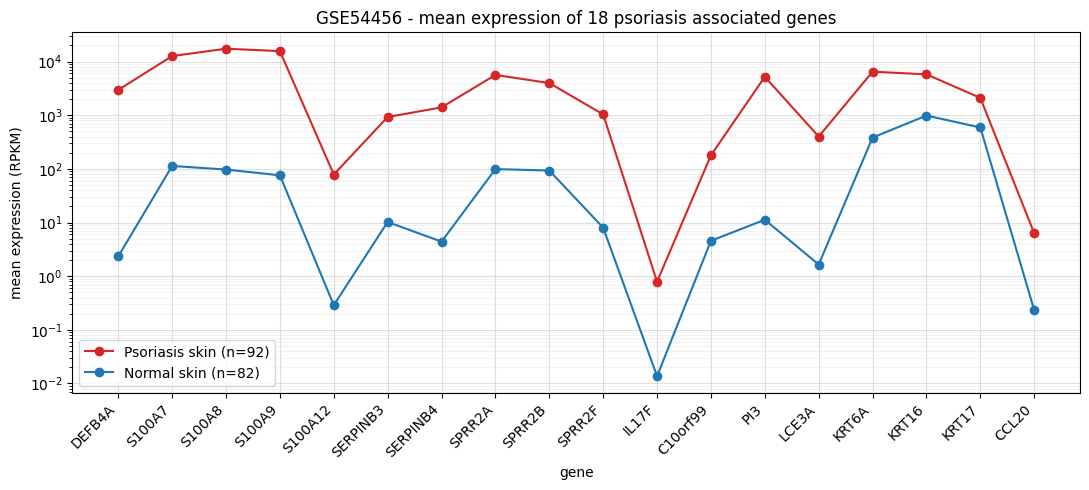

In [10]:
# 3(a)
# df restriced to 18 genes and  mean psoriasis plot,  (genes on x, expressio on y)

GENES = ['DEFB4A','S100A7','S100A8','S100A9','S100A12','SERPINB3','SERPINB4',
         'SPRR2A','SPRR2B','SPRR2F','IL17F','C10orf99','PI3','LCE3A', 'KRT6A','KRT16','KRT17','CCL20']

expr   = pd.read_csv(f'{DATA}/GSE54456_RPKM_samples.csv', index_col=0)
labels = pd.read_csv(f'{DATA}/GSE54456_labels.csv').iloc[0]

# aligned by name
assert set(labels.index) == set(expr.columns)
labels = labels.reindex(expr.columns)

psor = labels.index[labels == 'Psoriasis_skin']
norm = labels.index[labels == 'normal_skin']
print(f'{expr.shape[0]} genes x {expr.shape[1]} samples | sample count: psoriasis n={len(psor)}, normal n={len(norm)}')

df18 = expr.loc[GENES]
# print(df18.shape)

means = pd.DataFrame({'Psoriasis': df18[psor].mean(axis=1),
                      'Normal':    df18[norm].mean(axis=1)})
print(means.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(GENES))
ax.plot(x, means['Psoriasis'], 'o-', color='tab:red',  label=f'Psoriasis skin (n={len(psor)})')
ax.plot(x, means['Normal'], 'o-', color='tab:blue', label=f'Normal skin (n={len(norm)})')
ax.set_xticks(x)
ax.set_xticklabels(GENES, rotation=45, ha='right')
ax.set_yscale('log')
ax.set_xlabel('gene')
ax.set_ylabel('mean expression (RPKM)')
ax.set_title('GSE54456 - mean expression of 18 psoriasis associated genes')
ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15)
ax.legend()
fig.tight_layout()
fig.savefig(f'{RESULTS}/p3a_mean_expression.png', dpi=200)
plt.show()

          Psoriasis  Normal    ratio
DEFB4A      2964.65    2.34  1266.69
PI3         5205.22   11.28   461.35
SERPINB4    1402.12    4.40   318.38
S100A12       78.58    0.29   272.64
LCE3A        400.71    1.65   243.21
S100A9     15673.50   75.90   206.52
S100A8     17380.99   97.24   178.75
SPRR2F      1036.91    8.02   129.31
S100A7     12672.77  113.38   111.78
SERPINB3     927.19   10.25    90.44
IL17F          0.79    0.01    57.65
SPRR2A      5638.41   99.07    56.91
SPRR2B      3980.48   93.29    42.67
C10orf99     179.29    4.56    39.28
CCL20          6.31    0.23    27.02
KRT6A       6485.69  383.52    16.91
KRT16       5784.00  985.58     5.87
KRT17       2106.05  591.82     3.56

Largest psoriasis/normal ratio: DEFB4A(1266.7x)
DEFB4A 0s: psoriasis 0, normal 30


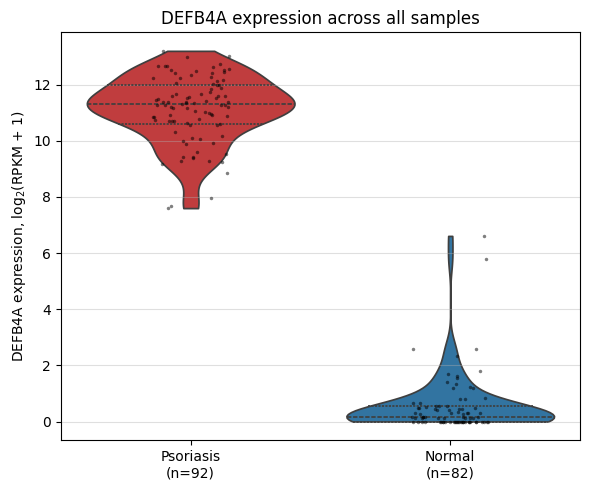

In [11]:
# 3(b)
# gene w largest ratio of avg expression b/n psoriasis and normal nad sns plot of that gene across all samples

ranked = means.assign(ratio=means['Psoriasis'] / means['Normal']).sort_values('ratio', ascending=False)
print(ranked.round(2))

top_gene = ranked.index[0]
print(f'\nLargest psoriasis/normal ratio: {top_gene}' f'({ranked.loc[top_gene, "ratio"]:.1f}x)')

vals = expr.loc[top_gene]
print(f'{top_gene} 0s: psoriasis {(vals[psor] == 0).sum()}, normal {(vals[norm] == 0).sum()}')

plot_df = pd.DataFrame({
    'group': labels.map({'Psoriasis_skin': 'Psoriasis', 'normal_skin': 'Normal'}),
    'log2(RPKM + 1)': np.log2(vals + 1),
})

palette = {'Psoriasis': 'tab:red', 'Normal': 'tab:blue'}
order = ['Psoriasis', 'Normal']

fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=plot_df, x='group', y='log2(RPKM + 1)', hue='group', order=order,
               palette=palette, inner='quart', cut=0, legend=False, ax=ax)
sns.stripplot(data=plot_df, x='group', y='log2(RPKM + 1)', order=order,
              color='k', size=2.5, alpha=0.5, jitter=0.15, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Psoriasis\n(n={len(psor)})', f'Normal\n(n={len(norm)})'])
ax.set_xlabel('')
ax.set_ylabel(f'{top_gene} expression, log$_2$(RPKM + 1)')
ax.set_title(f'{top_gene} expression across all samples')
ax.grid(True, axis='y', alpha=0.4)
fig.tight_layout()
fig.savefig(f'{RESULTS}/p3b_violin_{top_gene}.png', dpi=200)
plt.show()

mean(psoriasis) / mean(normal) computed for each gene in df and DEFB4A ranks first at 1266.7x ratio. 30 of 82 normal sample sare 0 RPKM, so the +1 in expression maps 0 to 0 and uses every sample.

411 genes excluded, 21099 genes tested
Up in psoriasis (p<0.05, >=2-fold): 489
Down in psoriasis (p<0.05, >=2-fold): 642
Not significant or <2-fold: 19968

top-right: largest |log2FC| = 10.57, largest -log10 p = 128.2
          log2FC  neglog10p
S100A7A     8.11     128.22
AKR1B10     5.19     120.57
DEFB4A     10.57     118.03
LCE3A       7.55     111.91
PI3         9.41     109.77
IL1F9       5.20     109.19
SERPINB4    8.31     107.33
GJB2        4.12     102.43

top-left: largest |log2FC| = 3.76, largest -log10 p = 88.8
          log2FC  neglog10p
ANKRD33B   -2.11      88.80
KRT77      -3.61      85.62
COBL       -1.53      81.25
RORC       -2.15      80.08
IL34       -2.54      78.51
F3         -2.19      77.08
INPP5A     -1.03      74.62
PHYHD1     -1.59      74.60
|log2FC| >= 2: up 121, down 59
|log2FC| >= 3: up 55, down 14
|log2FC| >= 4: up 33, down 0

 marked: 17 of 18; not marked: ['IL17F']


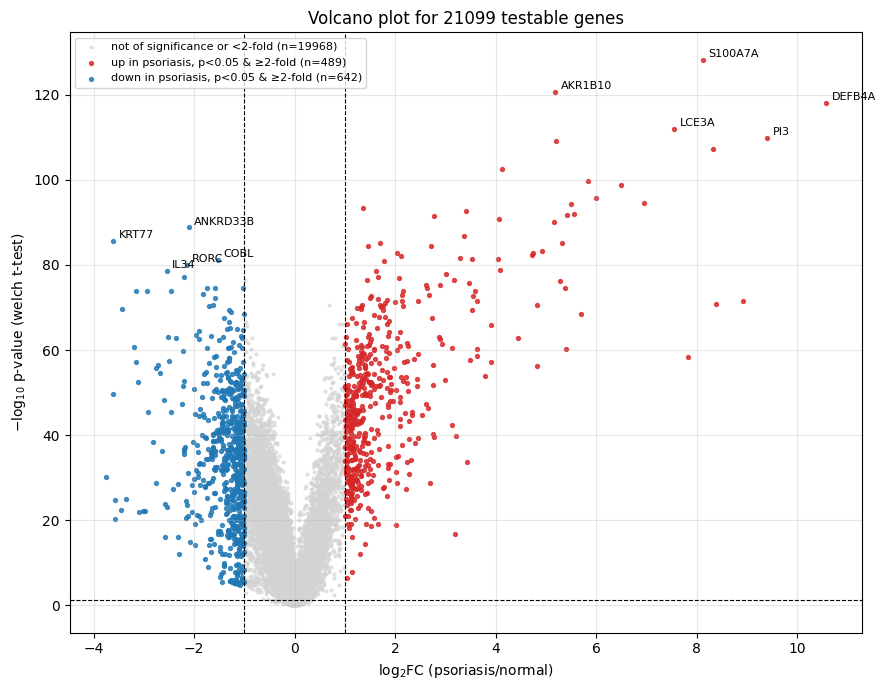

In [12]:
# 3(c)
# volcano plot of all genes, genes with p < 0.05 and logFC >= 1 marked by distinct color

expressed = expr.index[expr.sum(axis=1) > 0]
print(f'{len(expr) - len(expressed)} genes excluded, {len(expressed)} genes tested')

# 411 genes excluded because of all zero reads in all samples so testing is undefined

log_expr = np.log2(expr.loc[expressed] + 1)
lp, ln = log_expr[psor], log_expr[norm]

volcano = pd.DataFrame(index=expressed)
volcano['log2FC'] = lp.mean(axis=1) - ln.mean(axis=1)
# unequal group sizes and unequal spread so welsch t-test
volcano['p'] = stats.ttest_ind(lp, ln, axis=1, equal_var=False).pvalue   # Welch's t-test
volcano['neglog10p'] = -np.log10(volcano['p'])

sig = (volcano['p'] < 0.05) & (volcano['log2FC'].abs() >= 1) # p<0.05 and at least 2 fold change
up   = sig & (volcano['log2FC'] > 0)
down = sig & (volcano['log2FC'] < 0)
print(f'Up in psoriasis (p<0.05, >=2-fold): {up.sum()}')
print(f'Down in psoriasis (p<0.05, >=2-fold): {down.sum()}')
print(f'Not significant or <2-fold: {(~sig).sum()}')

for name, mask in [('top-right', up), ('top-left', down)]:
    v = volcano[mask]
    print(f'\n{name}: largest |log2FC| = {v["log2FC"].abs().max():.2f}, '
          f'largest -log10 p = {v["neglog10p"].max():.1f}')
    print(v.sort_values('neglog10p', ascending=False).head(8)[['log2FC', 'neglog10p']].round(2))

for t in [2, 3, 4]:
    print(f'|log2FC| >= {t}: up {(up & (volcano.log2FC >= t)).sum()}, down {(down & (volcano.log2FC <= -t)).sum()}')

print('\n marked:', int(sig[GENES].sum()), 'of 18; not marked:',
      [g for g in GENES if not sig[g]])

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(volcano.loc[~sig, 'log2FC'], volcano.loc[~sig, 'neglog10p'],
           s=4, c='lightgray', alpha=0.6, label=f'not of significance or <2-fold (n={(~sig).sum()})')
ax.scatter(volcano.loc[up, 'log2FC'], volcano.loc[up, 'neglog10p'],
           s=8, c='tab:red', alpha=0.8, label=f'up in psoriasis, p<0.05 & ≥2-fold (n={up.sum()})')
ax.scatter(volcano.loc[down, 'log2FC'], volcano.loc[down, 'neglog10p'],
           s=8, c='tab:blue', alpha=0.8, label=f'down in psoriasis, p<0.05 & ≥2-fold (n={down.sum()})')
ax.axhline(-np.log10(0.05), color='k', ls='--', lw=0.8)
ax.axvline(-1, color='k', ls='--', lw=0.8)
ax.axvline(1, color='k', ls='--', lw=0.8)

for mask in (up, down):
    for g, row in volcano[mask].nlargest(5, 'neglog10p').iterrows():
        ax.annotate(g, (row.log2FC, row.neglog10p), xytext=(4, 2),
                    textcoords='offset points', fontsize=8)

ax.set_xlabel('log$_2$FC (psoriasis/normal)')
ax.set_ylabel('$-$log$_{10}$ p-value (welch t-test)')
ax.set_title(f'Volcano plot for {len(expressed)} testable genes')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(f'{RESULTS}/p3c_volcano.png', dpi=200)
plt.show()

Raw ratio of averages will result in an infinite fold change because some some genes have 0 mean in a group. 489 genes are up in psoriasis and 642 are down. tested also on bonferroni correction, that count still holds true.

the top-right and top-left comparison, more genes are down in psoriasis than up but the corners are very distinct in magnitude.

* top-right log2FC = 10.6 and -log10p = 128.3

* top-left log2FC = -3.8 and -log10p = 89

So, the gene expression abnormalitiy in psoriasis tellsme that psoriasis is a disease of genes being turned on and not off. Because more gnes go down than up and the down ones only drop modestly (about 14 fold). The up ones jump by hundred to over a thousand fold. I looked up top right genes in AI and google and many turned out to be defense protein (DEFB4A, PI3, SERPINB3/B4) or gene that build outer skin layer (LCE3A, sprr2). SO, my interepretation is that psoriasis skin cells are in an overactive defend and grow state and that is consistent with psoriasis being an immune disorder.